In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error

In [2]:
df=pd.read_csv("/kaggle/input/datacamp-cources-rating/train.csv")

In [3]:
df.head()

,id,title,programming_language,difficulty_level,xp,time_needed_in_hours,topic_id,technology_id,content_area,nb_of_subscriptions,num_chapters,num_exercises,num_videos,datasets_count,difficulty_score,course_rating
0,16,Large Language Models (LLMs) Concepts,r,1,3300,2,16.0,7,Artificial Intelligence,66747,4,50,15,0,3.0,2.05
1,69,Introduction to Deep Learning in Python,python,2,3500,4,16.0,2,Artificial Intelligence,258161,4,50,17,3,3.0,2.38
2,32,Working with Hugging Face,python,1,2050,2,16.0,2,Artificial Intelligence,16188,2,26,8,4,3.0,2.18
3,25,Cleaning Data in Python,python,2,3500,4,18.0,2,Data Science and Analytics,140166,4,44,13,5,3.0,1.99
4,56,Linear Classifiers in Python,python,2,3200,4,6.0,2,Data Science and Analytics,61497,4,44,13,0,3.0,2.38


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    92 non-null     int64  
 1   title                 92 non-null     object 
 2   programming_language  92 non-null     object 
 3   difficulty_level      92 non-null     int64  
 4   xp                    92 non-null     int64  
 5   time_needed_in_hours  92 non-null     int64  
 6   topic_id              91 non-null     float64
 7   technology_id         92 non-null     int64  
 8   content_area          92 non-null     object 
 9   nb_of_subscriptions   92 non-null     int64  
 10  num_chapters          92 non-null     int64  
 11  num_exercises         92 non-null     int64  
 12  num_videos            92 non-null     int64  
 13  datasets_count        92 non-null     int64  
 14  difficulty_score      92 non-null     float64
 15  course_rating         92 

In [5]:
df.drop(columns=["id"],axis=1,inplace=True)

In [6]:
df.shape

(92, 15)

In [7]:
df.isnull().sum()

title                   0
programming_language    0
difficulty_level        0
xp                      0
time_needed_in_hours    0
topic_id                1
technology_id           0
content_area            0
nb_of_subscriptions     0
num_chapters            0
num_exercises           0
num_videos              0
datasets_count          0
difficulty_score        0
course_rating           0
dtype: int64

In [8]:
mode=df["topic_id"].mode()[0]
df["topic_id"]=df["topic_id"].fillna(mode)


categorical_cols = ['programming_language','content_area']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col]) 
    label_encoders[col] = le  

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 92 non-null     object 
 1   programming_language  92 non-null     int64  
 2   difficulty_level      92 non-null     int64  
 3   xp                    92 non-null     int64  
 4   time_needed_in_hours  92 non-null     int64  
 5   topic_id              92 non-null     float64
 6   technology_id         92 non-null     int64  
 7   content_area          92 non-null     int64  
 8   nb_of_subscriptions   92 non-null     int64  
 9   num_chapters          92 non-null     int64  
 10  num_exercises         92 non-null     int64  
 11  num_videos            92 non-null     int64  
 12  datasets_count        92 non-null     int64  
 13  difficulty_score      92 non-null     float64
 14  course_rating         92 non-null     float64
dtypes: float64(3), int64(11),

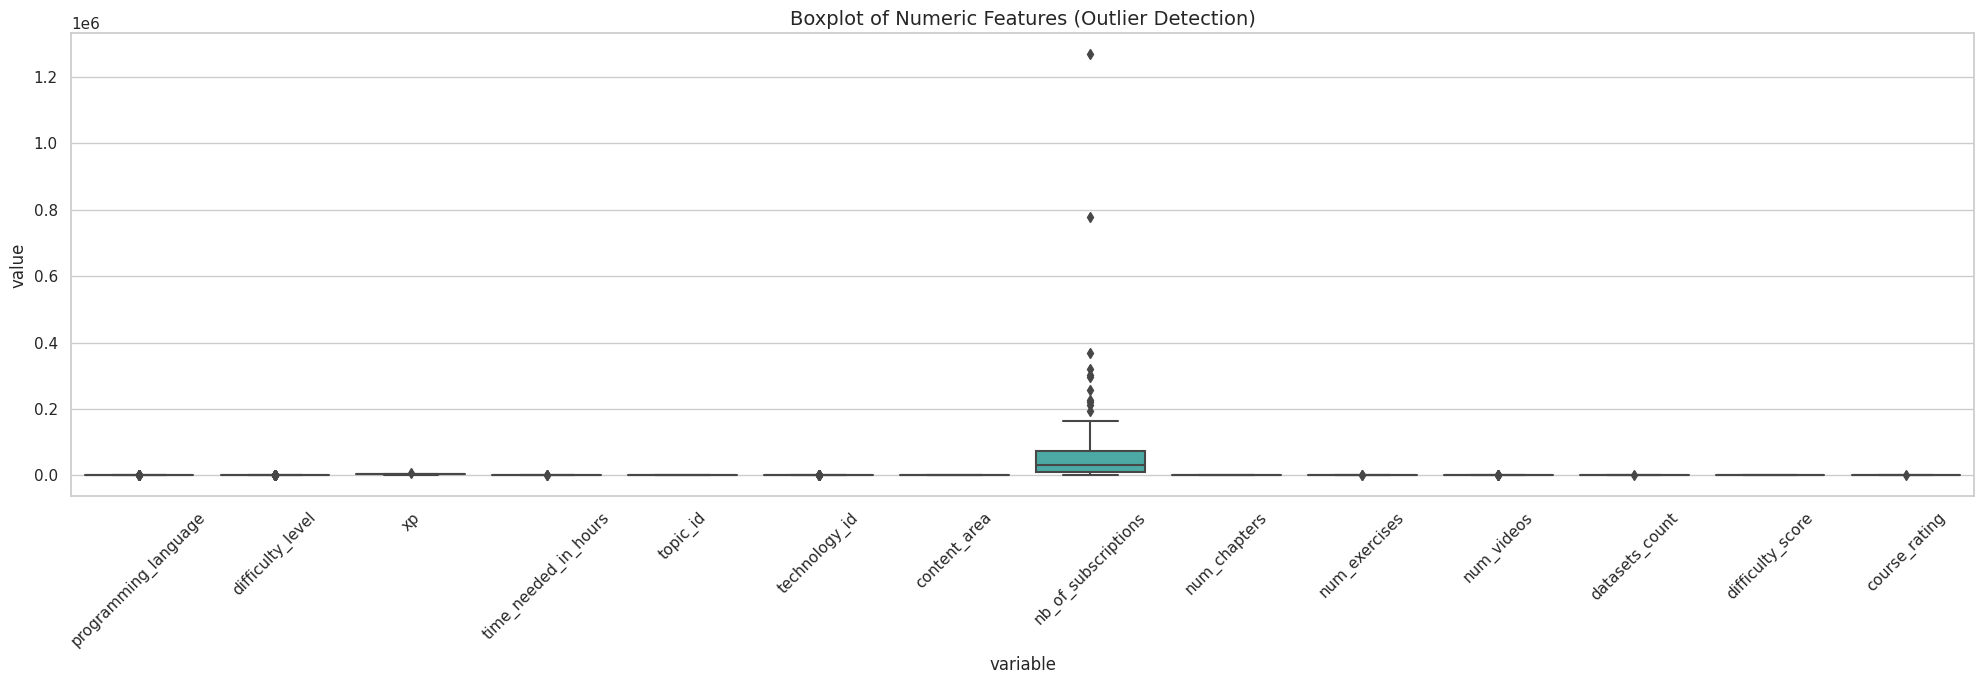

In [10]:
# Select only numeric columns for boxplot visualization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set the style and figure size
sns.set(style="whitegrid")
plt.figure(figsize=(20, 7))

# Create a boxplot for each numeric column
df_melted = df.melt(value_vars=numeric_cols)
sns.boxplot(x='variable', y='value', data=df_melted)

plt.title("Boxplot of Numeric Features (Outlier Detection)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
X=df.drop(columns=["course_rating"],axis=1)
y=df["course_rating"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train["nb_of_subscriptions"]=scaler.fit_transform(X_train["nb_of_subscriptions"].values.reshape(-1,1))
X_val["nb_of_subscriptions"]=scaler.transform(X_val["nb_of_subscriptions"].values.reshape(-1,1))

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=200, ngram_range=(1,2))
tfidf_train = tfidf.fit_transform(X_train['title']).toarray()
tfidf_val = tfidf.transform(X_val['title']).toarray()

tfidf_columns = [f'tfidf_{i}' for i in range(tfidf_train.shape[1])]

tfidf_train_df = pd.DataFrame(tfidf_train, columns=tfidf_columns, index=X_train.index)
tfidf_val_df = pd.DataFrame(tfidf_val, columns=tfidf_columns, index=X_val.index)
X_train_final = pd.concat([X_train.drop('title', axis=1), tfidf_train_df], axis=1)
X_val_final = pd.concat([X_val.drop('title', axis=1), tfidf_val_df], axis=1)

In [12]:
from sklearn.linear_model import Ridge

ridge_model = CatBoostRegressor(
    iterations=5000,       # number of trees
    learning_rate=0.1,
    depth=8,
    eval_metric='RMSE',    # you can also use MAE
    random_seed=42,
    verbose=100
)


ridge_model.fit(X_train_final, y_train)


y_pred_val = ridge_model.predict(X_val_final)
y_pred_val = np.clip(y_pred_val, 0.0, 5.0)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)
# Print all metrics
print(f"Validation Metrics for Random Forest:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

0:	learn: 0.4255270	total: 55.5ms	remaining: 4m 37s
100:	learn: 0.0625272	total: 218ms	remaining: 10.6s
200:	learn: 0.0127857	total: 452ms	remaining: 10.8s
300:	learn: 0.0033506	total: 621ms	remaining: 9.7s
400:	learn: 0.0009679	total: 765ms	remaining: 8.77s
500:	learn: 0.0002736	total: 906ms	remaining: 8.14s
600:	learn: 0.0000885	total: 1.03s	remaining: 7.56s
700:	learn: 0.0000299	total: 1.16s	remaining: 7.12s
800:	learn: 0.0000107	total: 1.3s	remaining: 6.79s
900:	learn: 0.0000035	total: 1.45s	remaining: 6.58s
1000:	learn: 0.0000012	total: 1.6s	remaining: 6.41s
1100:	learn: 0.0000004	total: 1.75s	remaining: 6.19s
1200:	learn: 0.0000001	total: 1.9s	remaining: 6.01s
1300:	learn: 0.0000001	total: 2.04s	remaining: 5.81s
1400:	learn: 0.0000000	total: 2.19s	remaining: 5.63s
1500:	learn: 0.0000000	total: 2.32s	remaining: 5.41s
1600:	learn: 0.0000000	total: 2.46s	remaining: 5.21s
1700:	learn: 0.0000000	total: 2.6s	remaining: 5.04s
1800:	learn: 0.0000000	total: 2.74s	remaining: 4.87s
1900:	le

In [13]:
test=pd.read_csv("/kaggle/input/datacamp-cources-rating/test.csv")
Id=test.id
test.drop(columns=["id"],axis=1,inplace=True)

for col in categorical_cols:
    le = label_encoders[col]
    # Map unseen labels to 'unknown'
    test[col] = test[col].apply(lambda x: x if x in le.classes_ else 'unknown')
    # Add 'unknown' to encoder classes
    if 'unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'unknown')
    # Transform
    test[col] = le.transform(test[col])


test["nb_of_subscriptions"]=scaler.transform(test["nb_of_subscriptions"].values.reshape(-1,1))
tfidf_test = tfidf.transform(test['title']).toarray()

tfidf_test_df = pd.DataFrame(tfidf_test, columns=tfidf_columns, index=test.index)
test_final = pd.concat([test.drop('title', axis=1), tfidf_test_df], axis=1)
y_pred=ridge_model.predict(test_final)
y_pred = np.clip(y_pred, 0.0, 5.0)
submission = pd.DataFrame({'id': Id,'course_rating': y_pred})
submission.to_csv('new_submission.csv', index=False)
submission.head()

,id,course_rating
0,84,1.826516
1,5,2.778700
2,43,1.557147
3,41,1.968266
4,11,1.727558


In [14]:
df=pd.read_csv("/kaggle/input/datacamp-cources-rating/train.csv")
print(f"Data Shape: {df.shape}")
print(f"Data info: {df.info()}")
print(f"Check Null Values: {df.isnull().sum()}")
df.drop(columns=["id","title"],axis=1,inplace=True)


Data Shape: (92, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    92 non-null     int64  
 1   title                 92 non-null     object 
 2   programming_language  92 non-null     object 
 3   difficulty_level      92 non-null     int64  
 4   xp                    92 non-null     int64  
 5   time_needed_in_hours  92 non-null     int64  
 6   topic_id              91 non-null     float64
 7   technology_id         92 non-null     int64  
 8   content_area          92 non-null     object 
 9   nb_of_subscriptions   92 non-null     int64  
 10  num_chapters          92 non-null     int64  
 11  num_exercises         92 non-null     int64  
 12  num_videos            92 non-null     int64  
 13  datasets_count        92 non-null     int64  
 14  difficulty_score      92 non-null     float64
 15  cour

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['programming_language', 'content_area']:
    df[col] = le.fit_transform(df[col])
df.head()

,programming_language,difficulty_level,xp,time_needed_in_hours,topic_id,technology_id,content_area,nb_of_subscriptions,num_chapters,num_exercises,num_videos,datasets_count,difficulty_score,course_rating
0,1,1,3300,2,16.0,7,0,66747,4,50,15,0,3.0,2.05
1,0,2,3500,4,16.0,2,0,258161,4,50,17,3,3.0,2.38
2,0,1,2050,2,16.0,2,0,16188,2,26,8,4,3.0,2.18
3,0,2,3500,4,18.0,2,3,140166,4,44,13,5,3.0,1.99
4,0,2,3200,4,6.0,2,3,61497,4,44,13,0,3.0,2.38


In [16]:
X=df.drop(columns=["course_rating"],axis=1)
y=df["course_rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_features = ['programming_language', 'content_area']

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)
y_pred_val = model.predict(X_val_final)
y_pred_val = np.clip(y_pred_val, 0.0, 5.0)
mse = mean_squared_error(y_val, y_pred_val)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)
# Print all metrics
print(f"Validation Metrics for Random Forest:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

0:	learn: 0.4331399	test: 0.4459021	best: 0.4459021 (0)	total: 2ms	remaining: 2s
100:	learn: 0.1860858	test: 0.2878311	best: 0.2878311 (100)	total: 80.6ms	remaining: 717ms
200:	learn: 0.1141325	test: 0.2816659	best: 0.2783204 (170)	total: 144ms	remaining: 573ms
300:	learn: 0.0742321	test: 0.2930158	best: 0.2783204 (170)	total: 213ms	remaining: 494ms
400:	learn: 0.0526957	test: 0.3017359	best: 0.2783204 (170)	total: 281ms	remaining: 420ms
500:	learn: 0.0401187	test: 0.3036263	best: 0.2783204 (170)	total: 346ms	remaining: 344ms
600:	learn: 0.0302828	test: 0.3050442	best: 0.2783204 (170)	total: 414ms	remaining: 275ms
700:	learn: 0.0231848	test: 0.3053736	best: 0.2783204 (170)	total: 481ms	remaining: 205ms
800:	learn: 0.0175254	test: 0.3059968	best: 0.2783204 (170)	total: 548ms	remaining: 136ms
900:	learn: 0.0132230	test: 0.3070708	best: 0.2783204 (170)	total: 611ms	remaining: 67.2ms
999:	learn: 0.0100093	test: 0.3073760	best: 0.2783204 (170)	total: 676ms	remaining: 0us

bestTest = 0.27832

In [17]:
test=pd.read_csv("/kaggle/input/datacamp-cources-rating/test.csv")
Id=test.id
test.drop(columns=["id","title"],axis=1,inplace=True)
le = LabelEncoder()
for col in ['programming_language', 'content_area']:
    test[col] = le.fit_transform(test[col])
    
model.fit(X,y)

y_pred=model.predict(test)
y_pred = np.clip(y_pred, 0.0, 5.0)
submission = pd.DataFrame({'id': Id,'course_rating': y_pred})
submission.to_csv('cat_submission.csv', index=False)
submission.head()

0:	learn: 0.4362175	total: 525us	remaining: 525ms
100:	learn: 0.1977659	total: 29.2ms	remaining: 260ms
200:	learn: 0.1285922	total: 59.9ms	remaining: 238ms
300:	learn: 0.0824226	total: 88.4ms	remaining: 205ms
400:	learn: 0.0568646	total: 116ms	remaining: 173ms
500:	learn: 0.0364807	total: 144ms	remaining: 143ms
600:	learn: 0.0267072	total: 172ms	remaining: 114ms
700:	learn: 0.0191498	total: 202ms	remaining: 86.4ms
800:	learn: 0.0137612	total: 231ms	remaining: 57.5ms
900:	learn: 0.0106415	total: 260ms	remaining: 28.6ms
999:	learn: 0.0079229	total: 288ms	remaining: 0us


,id,course_rating
0,84,1.617453
1,5,2.726577
2,43,1.527019
3,41,2.170735
4,11,1.437557
